# Non-equilibrium relaxation across $\tau_{\rm conf}$ + sequential basin folding

**Non-equilibrium experiments, varying conformational timescale.** for the same EX2 peptide, compared from an *equilibrium start* and an *all-open start* for threeconformational timescales 
$\tau^{\rm conf} \in \{0.1, 1, 10\}$
s (rows). Envelopes for the two initial conditions are shown in stacked    subpanels (top: equilibrium, bottom: all-open).

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

_here = os.getcwd()
_py   = os.path.abspath(os.path.join(_here, '..', 'python'))
if _py not in sys.path:
    sys.path.insert(0, _py)

import hdx_env as H
from hdx_env import (UncoupledResidues,
                     COLORS, LABELS,
                     uptake_from_survivals, moments_from_distribution)
H.set_plot_style(use_tex=False)

PLOTS_DIR = os.path.abspath(os.path.join(_here, '..', 'figures'))
os.makedirs(PLOTS_DIR, exist_ok=True)


/var/folders/81/krjk648s12s8qx5cqw7z83n00000gn/T/ipykernel_11773/3458060295.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(os.path.join(PLOTS_DIR, 'fig_nonequilibrium_HDX.png'),
/Users/antonio/miniconda3/envs/hdxenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


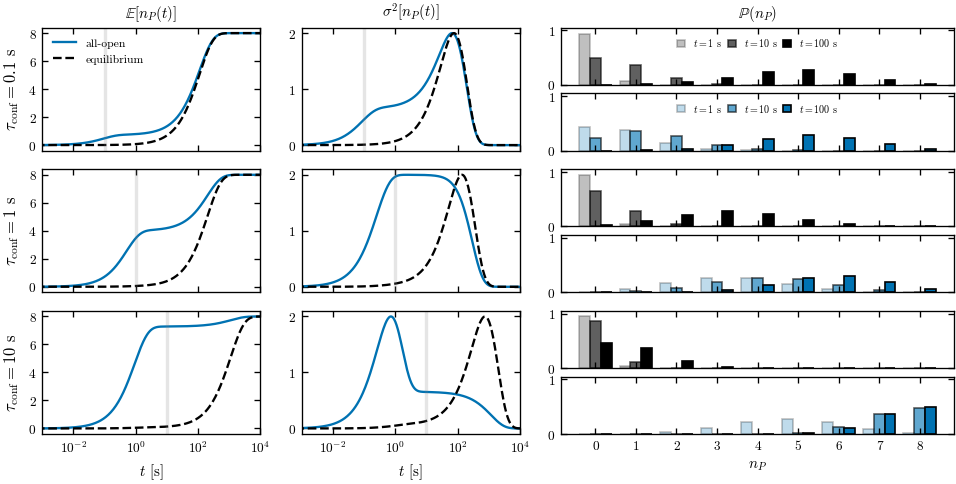

In [2]:
rng_ne = np.random.default_rng(42)
N_ne   = 8
P_ne   = tuple(range(N_ne))

# random log-uniform protection factors P_i in [1, 1e3] (shared across rows)
log10P = np.ones(N_ne) * 2
Pi_ne  = 10.0 ** log10P
pi_op  = 1.0 / (1.0 + Pi_ne)
k_int_ne = np.ones(N_ne)

from matplotlib.ticker import LogFormatterMathtext

xticks = [10**XX for XX in np.linspace(-2, 6, 5)]
xlabels = [rf'$10^{{{int(XX)}}}$' for XX in np.linspace(-2, 6, 5)]

p0_eq    = np.stack([1.0 - pi_op, pi_op], axis=1)            # equilibrium
p0_open  = np.stack([np.zeros(N_ne), np.ones(N_ne)], axis=1) # all-open

t_ne     = np.logspace(-4, 6, 501)
ts_show  = [1e0, 1e1, 1e2]
tau_list = [0.1, 1.0, 10.0]

alpha_eq = np.linspace(0.25, 1.0, len(ts_show))   # darkest = latest time

fig = plt.figure(figsize=(9.8, 4.4), tight_layout=True)
outer = fig.add_gridspec(len(tau_list), 3,
                         width_ratios=[1.0, 1.0, 1.8],
                         hspace=0.15, wspace=0.15)

for r, tau_conf in enumerate(tau_list):
    
    kop_ne   = pi_op / tau_conf
    kcl_ne   = (1.0 - pi_op) / tau_conf

    mod_eq   = UncoupledResidues(kop_ne, kcl_ne, k_int_ne, p0=p0_eq)
    mod_open = UncoupledResidues(kop_ne, kcl_ne, k_int_ne, p0=p0_open)

    m_eq, v_eq = mod_eq.centroid(P_ne, t_ne),   mod_eq.variance(P_ne, t_ne)
    m_op, v_op = mod_open.centroid(P_ne, t_ne), mod_open.variance(P_ne, t_ne)
    ud_eq      = mod_eq.uptake_distribution(P_ne, t_ne)
    ud_open    = mod_open.uptake_distribution(P_ne, t_ne)

    # ---- centroid -------------------------------------------------
    axc = fig.add_subplot(outer[r, 0])
    axc.plot(t_ne, m_op, color=COLORS['uncoupled'], lw=1.4, ls='-',
             label='all-open')
    axc.plot(t_ne, m_eq, color='k', ls='--', lw=1.4,
             label='equilibrium')
    #axc.scatter(ts_show, mod_open.centroid(P_ne, ts_show), color=COLORS['uncoupled'])
    #axc.scatter(ts_show, mod_eq.centroid(P_ne, ts_show), color='k')
    axc.axvline(tau_conf, color='0.5', lw=2, ls='-', alpha=.2)
    axc.set_xscale('log')
    axc.set_yticks(np.arange(0,8+2,2))
    axc.set_xticks([10**XX for XX in np.linspace(-2,6,5)], labels=[""]*5)
    #axc.set_ylabel(r'$\langle n_P\rangle$')
    if r == 0:
        axc.set_title(r'$\mathbb{E}[n_P(t)]$', fontsize=9)
        axc.legend(loc='upper left', fontsize=7)
    if r == len(tau_list) - 1:
        axc.set_xlabel(r'$t$ [s]')
        axc.set_xticks([10**XX for XX in np.linspace(-2,6,5)], labels=[rf'$10^{{{int(XX)}}}$' for XX in np.linspace(-2,6,5)])
    axc.set_xlim(10**-3, 10**4)


    # row label on the very left
    axc.text(-0.14, 0.5, fr'$\tau_{{\rm conf}} = {tau_conf:g}$ s',
             transform=axc.transAxes, fontsize=10, rotation=90,
             ha='center', va='center', fontweight='bold')

    # ---- variance -------------------------------------------------
    axv = fig.add_subplot(outer[r, 1])
    axv.plot(t_ne, v_op, color=COLORS['uncoupled'], lw=1.4, ls='-')
    axv.plot(t_ne, v_eq, color='k', ls='--',  lw=1.4)
    #axv.scatter(ts_show, mod_open.variance(P_ne, ts_show), color=COLORS['uncoupled'])
    #axv.scatter(ts_show, mod_eq.variance(P_ne, ts_show), color='k')
    axv.axvline(tau_conf, color='0.5', lw=2, ls='-', alpha=.2)
    axv.set_xscale('log')
    axv.set_xticks([10**XX for XX in np.linspace(-2,6,5)], labels=[""]*5)
    #axv.set_ylabel(r'$\sigma^2[n_P]$')
    if r == 0:
        axv.set_title(r'$\sigma^2[n_P(t)]$', fontsize=9)
    if r == len(tau_list) - 1:
        axv.set_xlabel(r'$t$ [s]')
        axv.set_xticks([10**XX for XX in np.linspace(-2,6,5)], labels=[rf'$10^{{{int(XX)}}}$' for XX in np.linspace(-2,6,5)])
    axv.set_xlim(10**-3, 10**4)

    # ---- envelopes: stacked (eq top, all-open bottom) -------------
    inner = outer[r, 2].subgridspec(2, 1, hspace=0.15)
    axE_eq = fig.add_subplot(inner[0, 0])
    axE_op = fig.add_subplot(inner[1, 0], sharex=axE_eq, sharey=axE_eq)

    nU = N_ne + 1
    xs = np.arange(nU)
    w  = 0.8 / len(ts_show)
    for k, ts in enumerate(ts_show):
        it     = int(np.argmin(np.abs(t_ne - ts)))
        offset = (k - (len(ts_show) - 1) / 2) * w
        axE_eq.bar(xs + offset, ud_eq[it],   w,
                   color='k', alpha=alpha_eq[k],
                   edgecolor='k', lw=1,
                   label=fr'$t = {ts:g}$ s' if r == 0 else None)
        axE_op.bar(xs + offset, ud_open[it], w,
                   color=COLORS['uncoupled'], alpha=alpha_eq[k],
                   edgecolor='k', lw=1,
                   label=fr'$t = {ts:g}$ s' if r == 0 else None)

    #axE_eq.set_ylabel('equilibrium',  fontsize=8)
    #axE_op.set_ylabel('all open',   fontsize=8)
    axE_eq.tick_params(labelbottom=False)
    axE_eq.set_xticks(xs, labels=[""]*len(xs)); axE_op.set_xticks(xs, labels=[""]*len(xs))
    axE_eq.set_ylim(0, 1.05)
    if r == 0:
        axE_eq.set_title(r'$\mathbb{P}(n_P)$', fontsize=9)
        axE_eq.legend(loc='upper center', fontsize=6,
                      ncol=len(ts_show), handlelength=0.8,
                      columnspacing=0.6, frameon=False)
        axE_op.legend(loc='upper center', fontsize=6,
                      ncol=len(ts_show), handlelength=0.8,
                      columnspacing=0.6, frameon=False)
    if r == len(tau_list) - 1:
        axE_op.set_xlabel(r'$n_P$')
        axE_op.set_xticks(xs, labels=xs)

        

fig.savefig(os.path.join(PLOTS_DIR, 'fig_nonequilibrium_HDX.png'),
            bbox_inches='tight', dpi=300)
plt.show()
